# Q1: Setup & Exploration

**Phase 1-2:** Project Setup, Data Exploration  
**Points: 6 points**

**Focus:** Load data, perform initial inspection, identify data quality issues.

**Lecture Reference:** See **Lecture 11, Notebook 1** (`11/demo/01_setup_exploration_cleaning.ipynb`), Phases 1-2 for examples of data loading, inspection, and initial visualizations.

---

## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os

# Create output directory
os.makedirs('output', exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Create output directory if it doesn't exist
os.makedirs('output', exist_ok=True)

In [2]:
#1) Load the dataset:
df = pd.read_csv('data/beach_sensors.csv')

#2) Inspect the data:
print("=== Inspecting Data ===")
df.shape # Check the shape of the dataframe
df.columns # Check the columns of the dataframe
df.dtypes # Check the data types of each column
df.head() # Display the first few rows of the dataframe
df.describe() # Get summary statistics of the dataframe

=== Inspecting Data ===


,Air Temperature,Wet Bulb Temperature,Humidity,Rain Intensity,Interval Rain,Total Rain,Precipitation Type,Wind Direction,Wind Speed,Maximum Wind Speed,Barometric Pressure,Solar Radiation,Heading,Battery Life
count,195817.000000,120156.000000,195892.000000,120156.000000,195892.000000,120156.000000,120156.000000,195892.000000,195892.000000,195892.00000,195746.000000,195892.000000,120156.000000,195892.000000
mean,12.649954,10.293835,68.021425,0.159070,0.142526,141.647773,4.255593,140.845241,2.919413,3.56009,994.309615,112.501705,281.835214,13.162528
std,10.429454,9.399146,15.638536,1.795549,1.097976,190.585115,15.568217,121.953309,5.347402,5.95980,10.033313,843.697961,142.861712,1.544512
min,-29.780000,-28.900000,0.000000,0.000000,-0.900000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,-100000.000000,0.000000,0.000000
25%,4.390000,3.000000,57.000000,0.000000,0.000000,16.700000,0.000000,11.000000,1.600000,1.20000,990.200000,0.000000,350.000000,11.900000
50%,13.780000,11.600000,69.000000,0.000000,0.000000,55.500000,0.000000,115.000000,2.900000,3.10000,994.400000,4.000000,354.000000,12.000000
75%,21.500000,18.400000,80.000000,0.000000,0.000000,201.300000,0.000000,260.000000,3.300000,5.20000,998.600000,131.000000,357.000000,15.100000
max,37.600000,28.400000,100.000000,183.600000,63.420000,1056.100000,70.000000,359.000000,999.900000,999.90000,3098.500000,1277.000000,359.000000,15.300000


In [3]:
#3) Parse datetime (if applicable):
#   - Identify datetime column(s)
#   - Parse using `pd.to_datetime()`
#   - Check date range# Parse datetime column if applicable

   # Assuming 'df' is your DataFrame and 'DateColumn' is the column to parse
df['Measurement Timestamp'] = pd.to_datetime(df['Measurement Timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Get the minimum and maximum dates in the column
start_date = df['Measurement Timestamp'].min()
end_date = df['Measurement Timestamp'].max()
print(f"\nDate Range: {start_date} to {end_date}")

print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Date Range: NaT to NaT

Column names:
['Station Name', 'Measurement Timestamp', 'Air Temperature', 'Wet Bulb Temperature', 'Humidity', 'Rain Intensity', 'Interval Rain', 'Total Rain', 'Precipitation Type', 'Wind Direction', 'Wind Speed', 'Maximum Wind Speed', 'Barometric Pressure', 'Solar Radiation', 'Heading', 'Battery Life', 'Measurement Timestamp Label', 'Measurement ID']

Data types:
Station Name                           object
Measurement Timestamp          datetime64[ns]
Air Temperature                       float64
Wet Bulb Temperature                  float64
Humidity                                int64
Rain Intensity                        float64
Interval Rain                         float64
Total Rain                            float64
Precipitation Type                    float64
Wind Direction                          int64
Wind Speed                            float64
Maximum Wind Speed                    float64
Barometric Pressure                   float64
Solar Radi

In [4]:
#4. **Identify missing values:**
#   - Count missing values per column: `df.isnull().sum()`
#   - Calculate percentages
missing_values = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100
print("\nMissing values:")
for col in df.columns:
    if missing_values[col] > 0:
        print(f"  {col}: {missing_values[col]} ({missing_percentages[col]:.1f}%)")


Missing values:
  Measurement Timestamp: 195892 (100.0%)
  Air Temperature: 75 (0.0%)
  Wet Bulb Temperature: 75736 (38.7%)
  Rain Intensity: 75736 (38.7%)
  Total Rain: 75736 (38.7%)
  Precipitation Type: 75736 (38.7%)
  Barometric Pressure: 146 (0.1%)
  Heading: 75736 (38.7%)


In [5]:
# Step 7: Get numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {numeric_cols}")

# Step 8: Calculate statistics for numeric columns
stats_df = df[numeric_cols].describe().T
stats_df['missing_count'] = df[numeric_cols].isnull().sum()
stats_df = stats_df[['mean', 'std', 'min', 'max', 'missing_count']]
stats_df['column_name'] = stats_df.index
stats_df = stats_df[['column_name', 'mean', 'std', 'min', 'max', 'missing_count']]
stats_df = stats_df.reset_index(drop=True)


Numeric columns: ['Air Temperature', 'Wet Bulb Temperature', 'Humidity', 'Rain Intensity', 'Interval Rain', 'Total Rain', 'Precipitation Type', 'Wind Direction', 'Wind Speed', 'Maximum Wind Speed', 'Barometric Pressure', 'Solar Radiation', 'Heading', 'Battery Life']


NameError: name 'df_indexed' is not defined

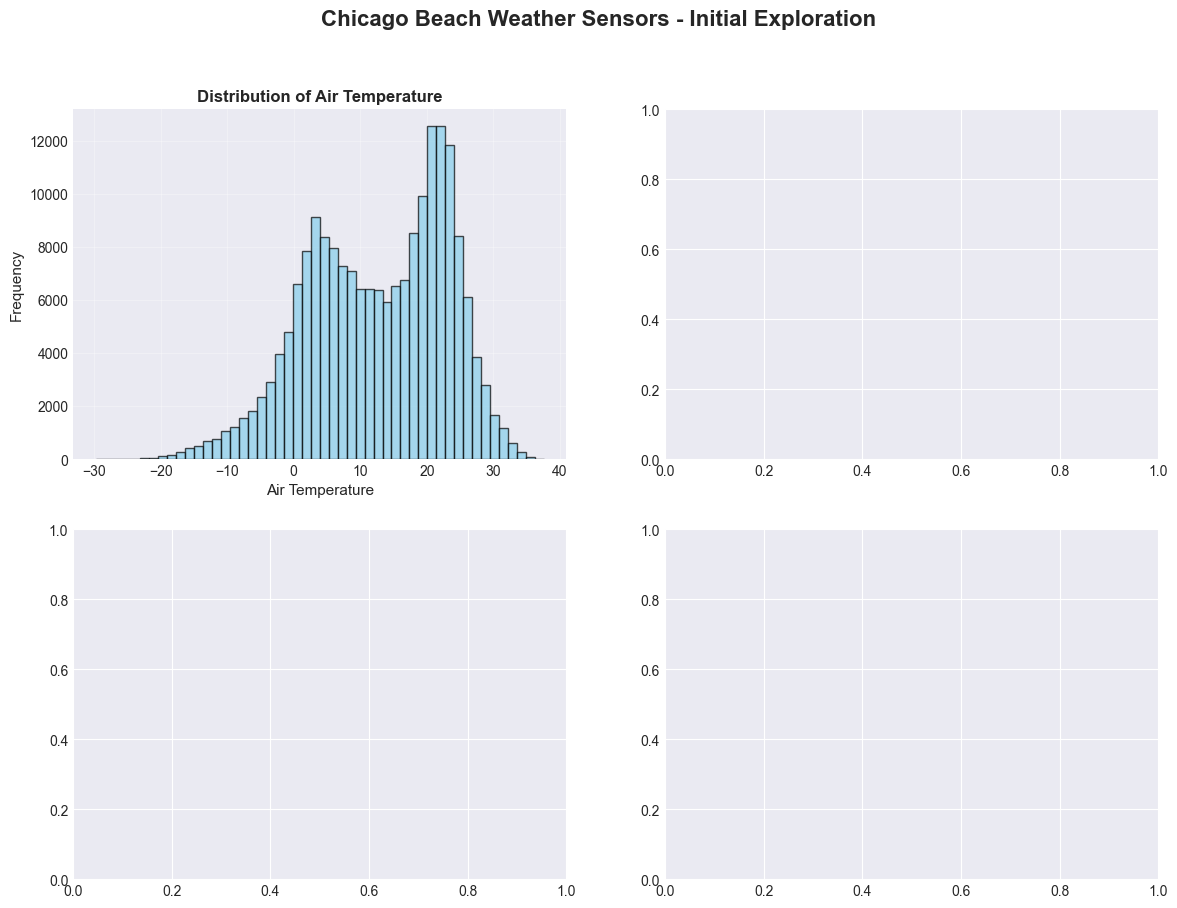

In [6]:

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chicago Beach Weather Sensors - Initial Exploration', fontsize=16, fontweight='bold')

# Plot 1: Distribution plot (histogram) - choose first numeric column
if len(numeric_cols) > 0:
    col1 = numeric_cols[0]
    axes[0, 0].hist(df[col1].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel(col1, fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].set_title(f'Distribution of {col1}', fontsize=12, fontweight='bold')
    axes[0, 0].grid(alpha=0.3)

# Plot 2: Time series plot - first numeric variable over time
if len(numeric_cols) > 0:
    # Resample to daily average for clearer visualization
    daily_avg = df_indexed[col1].resample('D').mean()
    axes[0, 1].plot(daily_avg.index, daily_avg.values, linewidth=1, color='coral')
    axes[0, 1].set_xlabel('Date', fontsize=11)
    axes[0, 1].set_ylabel(col1, fontsize=11)
    axes[0, 1].set_title(f'{col1} Over Time (Daily Average)', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

# Plot 3: Distribution of second numeric column (if available)
if len(numeric_cols) > 1:
    col2 = numeric_cols[1]
    axes[1, 0].hist(df[col2].dropna(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel(col2, fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].set_title(f'Distribution of {col2}', fontsize=12, fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

# Plot 4: Time series of second numeric column (if available)
if len(numeric_cols) > 1:
    daily_avg2 = df_indexed[col2].resample('D').mean()
    axes[1, 1].plot(daily_avg2.index, daily_avg2.values, linewidth=1, color='mediumpurple')
    axes[1, 1].set_xlabel('Date', fontsize=11)
    axes[1, 1].set_ylabel(col2, fontsize=11)
    axes[1, 1].set_title(f'{col2} Over Time (Daily Average)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

# Adjust layout and save
#    - Save figure to `output/q1_visualizations.png`
plt.tight_layout()
plt.savefig('output/q1_visualizations.png', dpi=150, bbox_inches='tight')
print("✓ Saved: output/q1_visualizations.png")
plt.show()

In [ ]:
# 6. **Save artifacts:**
#    - Write data info to `output/q1_data_info.txt`
#    - Write exploration stats to `output/q1_exploration.csv`

with open('output/q1_data_info.txt', 'w') as f:
    f.write(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n\n")
    
    f.write("Column Names:\n")
    for col in df.columns:
        f.write(f"- {col}\n")
    
    f.write("\nData Types:\n")
    for col, dtype in df.dtypes.items():
        f.write(f"- {col}: {dtype}\n")
    
    f.write(f"\nDate Range:\n")
    f.write(f"Start: {start_date}\n")
    f.write(f"End: {end_date}\n")
    
    f.write("\nMissing Values:\n")
    for col in df.columns:
        count = missing_values[col]
        pct = missing_percentages[col]
        f.write(f"- {col}: {count} ({pct:.1f}%)\n")

print("\n✓ Saved: output/q1_data_info.txt")

# ========================================
# SAVE ARTIFACT 2: q1_exploration.csv
# ========================================
stats_df.to_csv('output/q1_exploration.csv', index=False)
print("✓ Saved: output/q1_exploration.csv")


✓ Saved: output/q1_data_info.txt
✓ Saved: output/q1_exploration.csv


In [ ]:
## Decision Points

# - **Visualization choices:** What types of plots best show your data? See Lecture 11 Notebook 1 for examples.
# - **Data quality assessment:** What issues do you see? Missing data patterns? Outliers? Inconsistent formats? Document these for Q2.


---

## Objective

Load the Chicago Beach Weather Sensors dataset, perform initial inspection, and identify data quality issues.

**Time Series Note:** Unlike the lecture's NYC Taxi data (event-based), this dataset is **time-series data** with continuous sensor readings. The data is already indexed by time, so you'll work with datetime-indexed dataframes throughout. See **Lecture 09** for time series operations. For time series visualizations, you may want to use pandas `resample()` to aggregate data (e.g., daily averages) for clearer visualization of long-term trends.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q1_data_info.txt`
**Format:** Plain text file
**Content:** Dataset information including:
- Dataset shape (rows × columns)
- Column names (one per line or comma-separated)
- Data types for each column
- Date range (start date and end date) - **REQUIRED if temporal data**
- Missing value counts for each column (column name: count)

**Example format:**
```
Dataset Shape: 50000 rows × 10 columns

Column Names:
- Measurement Timestamp
- Beach
- Water Temperature
- Air Temperature
...

Data Types:
- Measurement Timestamp: datetime64[ns]
- Beach: object
- Water Temperature: float64
...

Date Range:
Start: 2022-01-01 00:00:00
End: 2027-09-15 07:00:00

Missing Values:
- Water Temperature: 2500 (5.0%)
- Air Temperature: 1500 (3.0%)
...
```

### 2. `output/q1_exploration.csv`
**Format:** CSV file
**Required Columns (exact names):** `column_name`, `mean`, `std`, `min`, `max`, `missing_count`
**Content:** One row per numeric column in the dataset
- `column_name`: Name of the numeric column
- `mean`: Mean value (float)
- `std`: Standard deviation (float)
- `min`: Minimum value (float)
- `max`: Maximum value (float)
- `missing_count`: Number of missing values (integer)

**Example:**
```csv
column_name,mean,std,min,max,missing_count
Water Temperature,15.23,5.12,0.5,28.7,2500
Air Temperature,18.45,8.23,-5.2,35.8,1500
Wind Speed,6.78,4.56,0.1,25.3,0
```

### 3. `output/q1_visualizations.png`
**Format:** PNG image file
**Content:** At least 2 plots in a single figure (use subplots)
**Required plots:**
1. **Distribution plot:** Histogram or density plot of at least one numeric variable
2. **Time series plot:** Line plot showing a numeric variable over time (if temporal data)

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

---

## Requirements Checklist

- [ ] Data loaded successfully from `data/beach_sensors.csv`
- [ ] Initial inspection completed (shape, info, head, describe)
- [ ] Missing values identified and counted
- [ ] Basic visualizations created (at least 2 plots: distribution + time series)
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Load the dataset:**
   ```python
   df = pd.read_csv('data/beach_sensors.csv')
   ```

2. **Inspect the data:**
   - Check shape: `df.shape`
   - Check columns: `df.columns`
   - Check data types: `df.dtypes`
   - Check head: `df.head()`
   - Check summary: `df.describe()`

3. **Parse datetime (if applicable):**
   - Identify datetime column(s)
   - Parse using `pd.to_datetime()`
   - Check date range

4. **Identify missing values:**
   - Count missing values per column: `df.isnull().sum()`
   - Calculate percentages

5. **Create visualizations:**
   - Distribution plot (histogram or density)
   - Time series plot (if temporal data)

6. **Save artifacts:**
   - Write data info to `output/q1_data_info.txt`
   - Write exploration stats to `output/q1_exploration.csv`
   - Save figure to `output/q1_visualizations.png`

---

## Decision Points

- **Visualization choices:** What types of plots best show your data? See Lecture 11 Notebook 1 for examples.
- **Data quality assessment:** What issues do you see? Missing data patterns? Outliers? Inconsistent formats? Document these for Q2.

---

## Checkpoint

After Q1, you should have:
- [ ] Data loaded successfully
- [ ] Basic statistics calculated
- [ ] Initial visualizations created (2+ plots)
- [ ] Data quality issues identified
- [ ] All 3 artifacts saved: `q1_data_info.txt`, `q1_exploration.csv`, `q1_visualizations.png`

---

**Next:** Continue to `q2_data_cleaning.md` for Data Cleaning.
